<a href="https://colab.research.google.com/github/abhinavpd099/Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Major Project: Seasonal Agriculture Performance Analysis


**Major Data Analytics Project**

**Domain**: Agriculture

**Project Theme**: Seasonal Agriculture Performance

**Tools**: Python, NumPy, Matplotlib, Seaborn

**Project Goal**

Investigate how agriculture performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.


**1. Problem Statement**

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

**2. Project Objectives**


Explore and understand the dataset.

Clean and prepare the data for analysis.

Examine how agricultural performance varies across seasons.

Identify important seasonal patterns and trends.

Investigate relationships between seasonal conditions and agricultural outcomes.

Compare relevant groups within different seasons.

Identify significant differences or unusual patterns.

Apply appropriate statistical and visualization techniques.

Interpret findings based on evidence from the dataset.

Develop meaningful conclusions and data-driven recommendations.


**3. Dataset:**

 `seasonal_agriculture_performance_dataset.csv`


In [ ]:
# 1. Import libraries and load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

print('Dataset shape:', df.shape)
display(df.head())
print('\nData types:')
display(df.dtypes.to_frame('dtype'))


Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30



Data types:


,dtype
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


## 2. Dataset understanding and data-quality check

In [ ]:
# Basic structure, duplicates and missing values
print('Rows:', len(df))
print('Columns:', len(df.columns))
print('Duplicate rows:', df.duplicated().sum())

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pct})
display(missing_report[missing_report['Missing_Count'] > 0])

print('\nUnique values in key categorical fields:')
for col in ['State', 'Crop', 'Season', 'Irrigation_Method']:
    print(f'\n{col}:', df[col].nunique())
    print(df[col].value_counts())


Rows: 4000
Columns: 28
Duplicate rows: 0


,Missing_Count,Missing_%
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80



Unique values in key categorical fields:

State: 8
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

Crop: 8
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season: 3
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method: 4
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [ ]:
# Descriptive statistics
display(df.describe(include='all').T)

# Numerical summary by season
season_summary = df.groupby('Season').agg(
    Farms=('Farm_ID','count'),
    Avg_Yield_t_ha=('Yield_Tonnes_Ha','mean'),
    Avg_Production_t=('Production_Tonnes','mean'),
    Avg_Revenue_INR=('Revenue_INR','mean'),
    Avg_Cost_INR=('Total_Cost_INR','mean'),
    Avg_Profit_INR=('Profit_INR','mean'),
    Avg_Rainfall_mm=('Rainfall_mm','mean'),
    Avg_Water_Used_m3=('Water_Used_m3','mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct','mean')
).round(2)
display(season_summary)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.00",NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",NaN,NaN,NaN,601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


,Farms,Avg_Yield_t_ha,Avg_Production_t,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Avg_Rainfall_mm,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Risk_pct
Season,,,,,,,,,,
Kharif,1779,5.64,46.31,"710,719.06","531,804.41","178,914.65",852.08,"6,102.20",5.89,54.47
Rabi,1627,5.08,41.49,"601,526.05","513,836.58","87,689.47",436.00,"5,846.99",5.19,40.48
Zaid,594,4.67,38.89,"519,171.90","543,976.73","-24,804.82",299.42,"6,419.89",4.41,38.22


## 3. Data cleaning and preparation
Missing numeric values are imputed with the median so that observations are retained for analysis. Duplicate rows are removed if present.

In [ ]:
# Clean a copy of the dataset
clean = df.copy()

# Remove exact duplicates
clean = clean.drop_duplicates().copy()

# Median imputation for numeric columns with missing values
numeric_cols = clean.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if clean[col].isna().any():
        clean[col] = clean[col].fillna(clean[col].median())

print('Shape after cleaning:', clean.shape)
print('Remaining missing values:', clean.isna().sum().sum())
display(clean.head())


Shape after cleaning: (4000, 28)
Remaining missing values: 0


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 4. Key analytical questions
1. How does agricultural performance vary across seasons?
2. What major seasonal patterns occur in yield, production and profit?
3. How do rainfall, temperature, humidity and soil moisture vary by season?
4. How does resource usage, especially water and fertilizer, differ across seasons?
5. Are seasonal conditions related to agricultural outcomes?
6. Do irrigation methods show performance differences?
7. Which crops/seasons show unusually high or low economic performance?
8. What evidence-based recommendations follow from the observed patterns?

## 5. Seasonal performance analysis

In [ ]:
# Performance by season
performance = clean.groupby('Season').agg(
    Avg_Yield_t_ha=('Yield_Tonnes_Ha','mean'),
    Median_Yield_t_ha=('Yield_Tonnes_Ha','median'),
    Avg_Production_t=('Production_Tonnes','mean'),
    Avg_Revenue_INR=('Revenue_INR','mean'),
    Avg_Cost_INR=('Total_Cost_INR','mean'),
    Avg_Profit_INR=('Profit_INR','mean'),
    Profit_Margin_pct=('Profit_INR', lambda x: (x.sum()/clean.loc[x.index,'Revenue_INR'].sum())*100),
    Avg_Water_Used_m3=('Water_Used_m3','mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct','mean')
).round(2)
display(performance.sort_values('Avg_Profit_INR', ascending=False))


,Avg_Yield_t_ha,Median_Yield_t_ha,Avg_Production_t,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Profit_Margin_pct,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Risk_pct
Season,,,,,,,,,,
Kharif,5.63,1.94,46.31,"710,719.06","531,804.41","178,914.65",25.17,"6,102.20",5.89,54.47
Rabi,5.04,1.67,41.49,"601,526.05","513,836.58","87,689.47",14.58,"5,846.99",5.19,40.48
Zaid,4.64,1.46,38.89,"519,171.90","543,976.73","-24,804.82",-4.78,"6,419.89",4.41,38.22


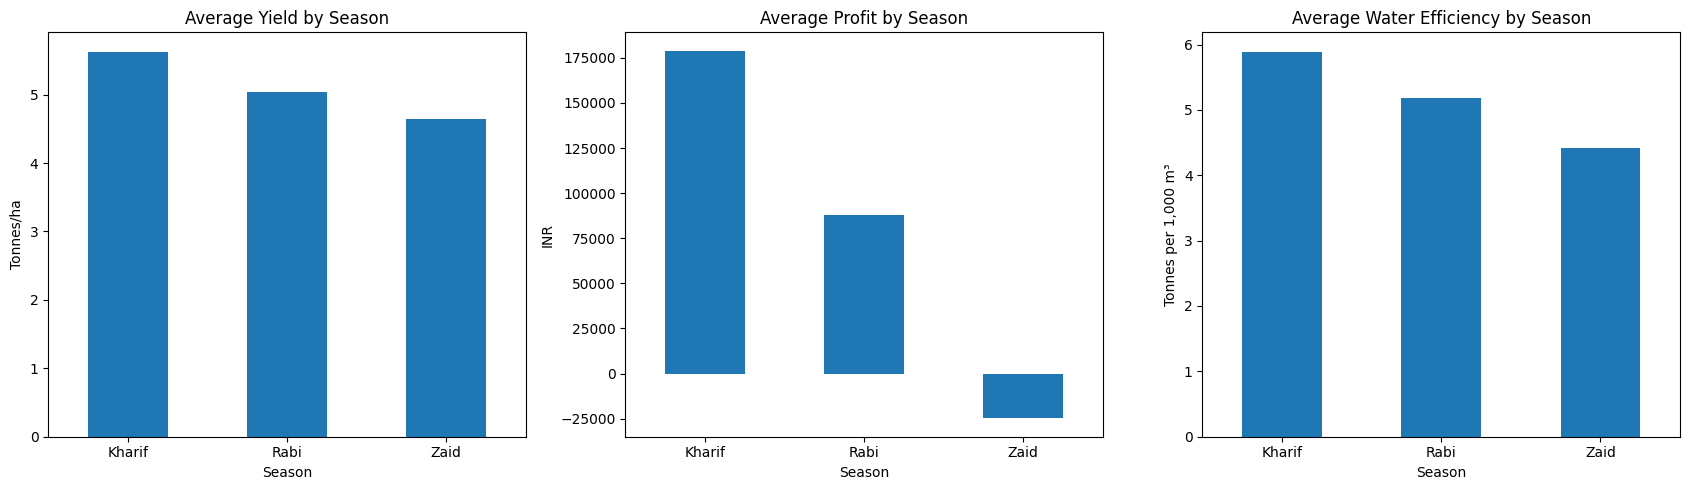

In [ ]:
# Visual comparison of major performance measures
season_order = ['Kharif','Rabi','Zaid']
s = clean.groupby('Season')[['Yield_Tonnes_Ha','Profit_INR','Water_Efficiency_t_per_1000m3']].mean().reindex(season_order)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
s['Yield_Tonnes_Ha'].plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Yield by Season'); axes[0].set_ylabel('Tonnes/ha'); axes[0].tick_params(axis='x', rotation=0)

s['Profit_INR'].plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Profit by Season'); axes[1].set_ylabel('INR'); axes[1].tick_params(axis='x', rotation=0)

s['Water_Efficiency_t_per_1000m3'].plot(kind='bar', ax=axes[2])
axes[2].set_title('Average Water Efficiency by Season'); axes[2].set_ylabel('Tonnes per 1,000 m³'); axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 6. Seasonal environmental conditions

,Rainfall_mm,Temperature_C,Humidity_pct,Sunlight_Hours,Soil_Moisture_pct,Soil_pH
Season,,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15,6.73
Rabi,437.62,23.49,57.89,7.59,24.07,6.67
Zaid,304.65,31.04,52.01,8.18,19.28,6.69


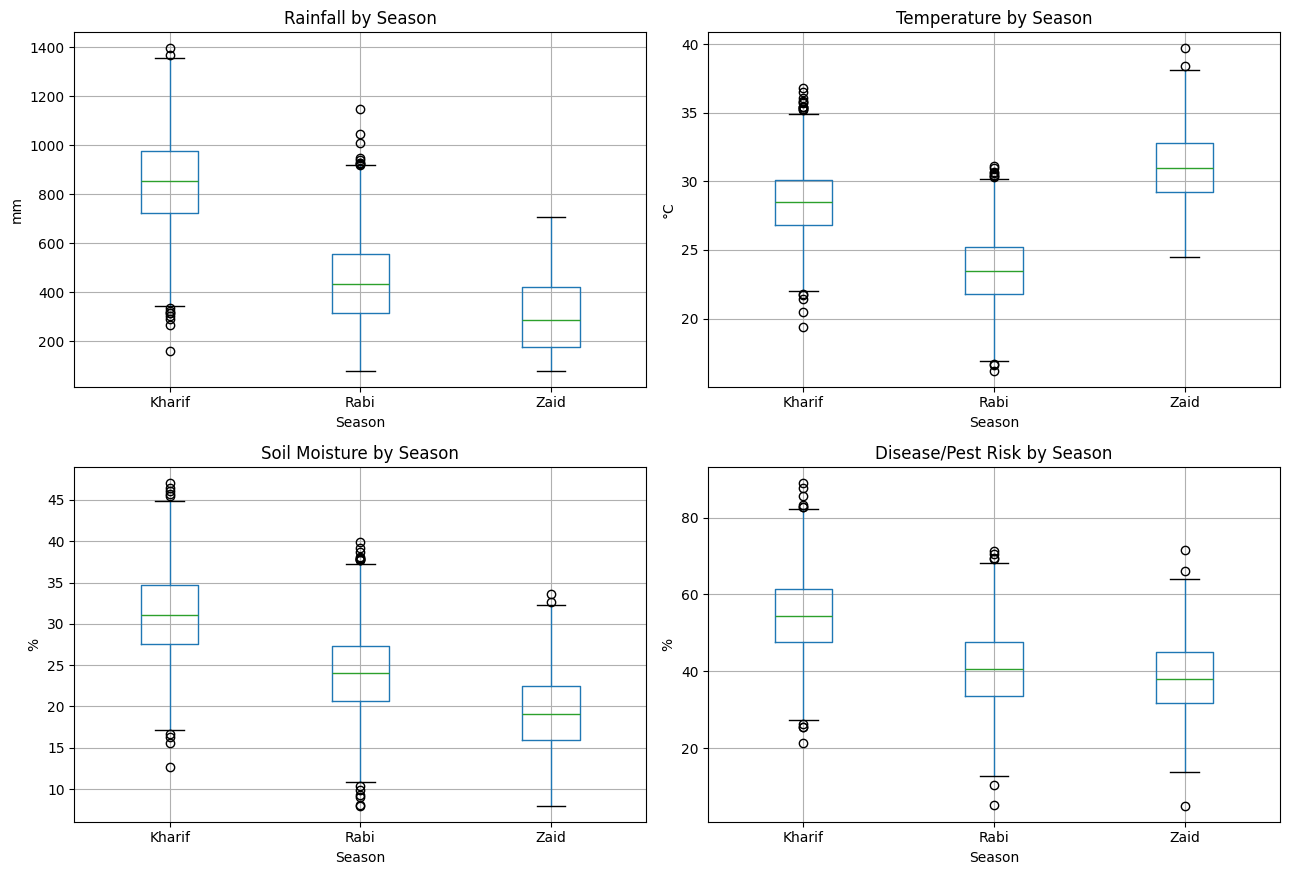

In [ ]:
environment = clean.groupby('Season').agg(
    Rainfall_mm=('Rainfall_mm','mean'),
    Temperature_C=('Avg_Temperature_C','mean'),
    Humidity_pct=('Humidity_pct','mean'),
    Sunlight_Hours=('Sunlight_Hours_Day','mean'),
    Soil_Moisture_pct=('Soil_Moisture_pct','mean'),
    Soil_pH=('Soil_pH','mean')
).round(2)
display(environment)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
clean.boxplot(column='Rainfall_mm', by='Season', ax=axes[0,0])
axes[0,0].set_title('Rainfall by Season'); axes[0,0].set_xlabel('Season'); axes[0,0].set_ylabel('mm')
clean.boxplot(column='Avg_Temperature_C', by='Season', ax=axes[0,1])
axes[0,1].set_title('Temperature by Season'); axes[0,1].set_xlabel('Season'); axes[0,1].set_ylabel('°C')
clean.boxplot(column='Soil_Moisture_pct', by='Season', ax=axes[1,0])
axes[1,0].set_title('Soil Moisture by Season'); axes[1,0].set_xlabel('Season'); axes[1,0].set_ylabel('%')
clean.boxplot(column='Disease_Pest_Risk_pct', by='Season', ax=axes[1,1])
axes[1,1].set_title('Disease/Pest Risk by Season'); axes[1,1].set_xlabel('Season'); axes[1,1].set_ylabel('%')
plt.suptitle('')
plt.tight_layout()
plt.show()


## 7. Resource usage and irrigation

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency,Seed_Quality
Season,,,,,
Kharif,187.08,5.08,"6,102.20",5.89,0.82
Rabi,185.41,5.02,"5,846.99",5.19,0.83
Zaid,184.64,5.17,"6,419.89",4.41,0.82


,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency
Irrigation_Method,,,,,
Drip,915,6.58,"219,626.00","5,918.75",6.27
Sprinkler,734,5.16,"91,121.08","6,208.26",4.67
Rainfed,1041,4.60,"79,050.37","3,549.55",7.56
Flood,1310,4.86,"73,354.02","8,026.47",3.44


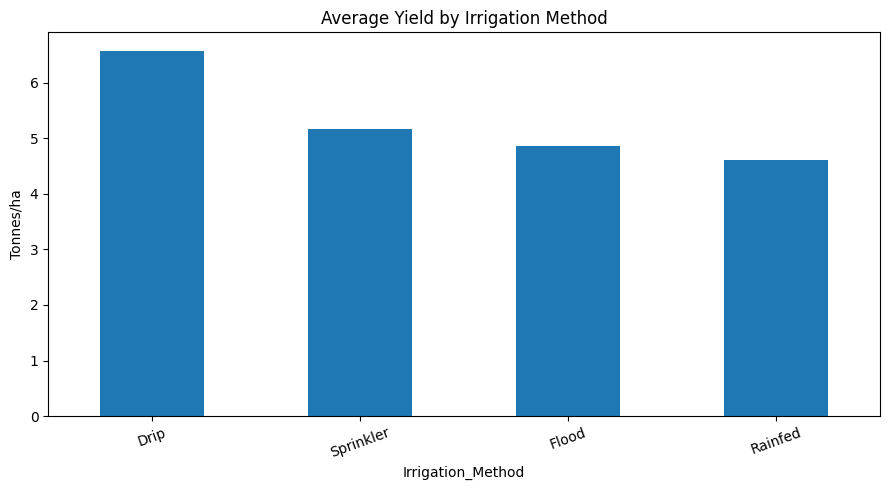

In [ ]:
resource = clean.groupby('Season').agg(
    Fertilizer_kg_ha=('Fertilizer_kg_ha','mean'),
    Pesticide_Litre_ha=('Pesticide_Litre_ha','mean'),
    Water_Used_m3=('Water_Used_m3','mean'),
    Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean'),
    Seed_Quality=('Seed_Quality_Score','mean')
).round(2)
display(resource)

irrigation = clean.groupby('Irrigation_Method').agg(
    Farms=('Farm_ID','count'),
    Avg_Yield=('Yield_Tonnes_Ha','mean'),
    Avg_Profit=('Profit_INR','mean'),
    Avg_Water_Used=('Water_Used_m3','mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean')
).sort_values('Avg_Profit', ascending=False).round(2)
display(irrigation)

plt.figure(figsize=(9,5))
irrigation_yield = clean.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)
irrigation_yield.plot(kind='bar')
plt.title('Average Yield by Irrigation Method')
plt.ylabel('Tonnes/ha')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 8. Crop-level and region-level comparisons

,Farms,Avg_Yield,Avg_Revenue,Avg_Profit,Avg_Water_Efficiency
Crop,,,,,
Sugarcane,305,46.64,"1,371,980.11","817,187.99",30.48
Chilli,412,1.54,"1,276,777.23","750,878.34",2.95
Cotton,508,1.23,"639,423.08","124,546.92",1.94
Groundnut,424,1.32,"542,935.50","44,858.12",3.15
Pulses,496,0.92,"528,465.87","-4,238.05",2.90
Maize,551,2.71,"457,067.99","-83,978.33",5.60
Rice,690,2.43,"423,615.26","-102,213.50",1.95
Wheat,614,2.11,"400,104.89","-123,398.34",4.63


,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
State,,,,
Punjab,484,6.12,"136,025.64",5.62
Maharashtra,512,5.02,"135,428.86",5.28
Karnataka,489,5.69,"119,422.34",5.56
Tamil Nadu,485,4.88,"117,744.75",5.31
Gujarat,488,5.66,"117,568.24",5.58
Telangana,516,5.04,"108,829.62",5.46
Madhya Pradesh,497,4.99,"86,840.76",5.27
Andhra Pradesh,529,4.63,"73,453.53",5.03


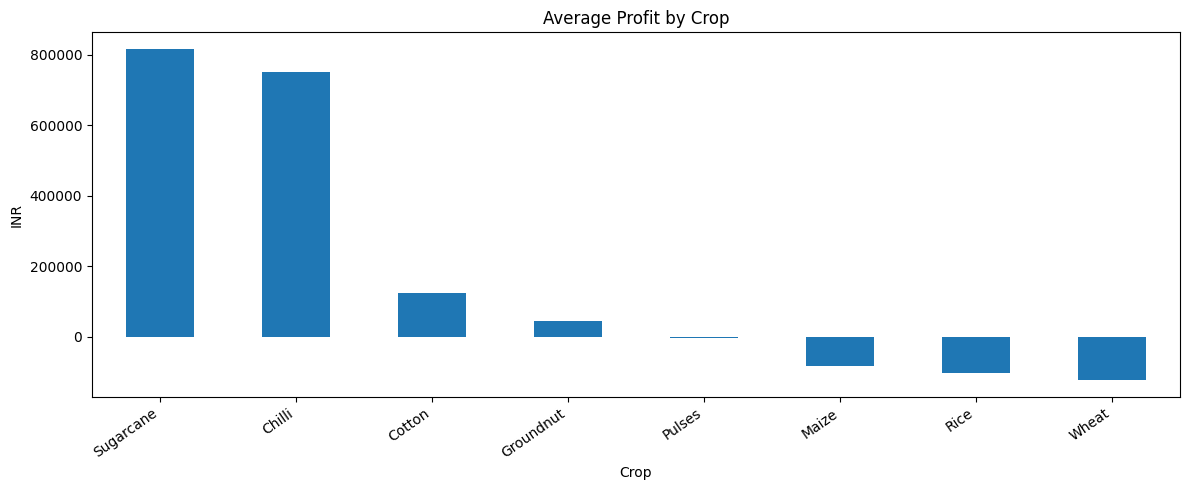

In [ ]:
crop_perf = clean.groupby('Crop').agg(
    Farms=('Farm_ID','count'),
    Avg_Yield=('Yield_Tonnes_Ha','mean'),
    Avg_Revenue=('Revenue_INR','mean'),
    Avg_Profit=('Profit_INR','mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean')
).sort_values('Avg_Profit', ascending=False).round(2)
display(crop_perf)

state_perf = clean.groupby('State').agg(
    Farms=('Farm_ID','count'),
    Avg_Yield=('Yield_Tonnes_Ha','mean'),
    Avg_Profit=('Profit_INR','mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean')
).sort_values('Avg_Profit', ascending=False).round(2)
display(state_perf)

plt.figure(figsize=(12,5))
crop_profit_plot = clean.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)
crop_profit_plot.plot(kind='bar')
plt.xticks(rotation=35, ha='right')
plt.title('Average Profit by Crop')
plt.ylabel('INR')
plt.tight_layout()
plt.show()


## 9. Relationships between conditions, resources and outcomes

,Yield_Tonnes_Ha,Profit_INR
Profit_INR,0.49,1.00
Revenue_INR,0.43,0.89
Water_Efficiency_t_per_1000m3,0.91,0.49
Yield_Tonnes_Ha,1.00,0.49
Water_Used_m3,0.39,0.19
Rainfall_mm,0.03,0.11
Soil_Moisture_pct,0.01,0.09
Nitrogen_kg_ha,0.05,0.09
Disease_Pest_Risk_pct,0.01,0.07
Humidity_pct,0.01,0.06


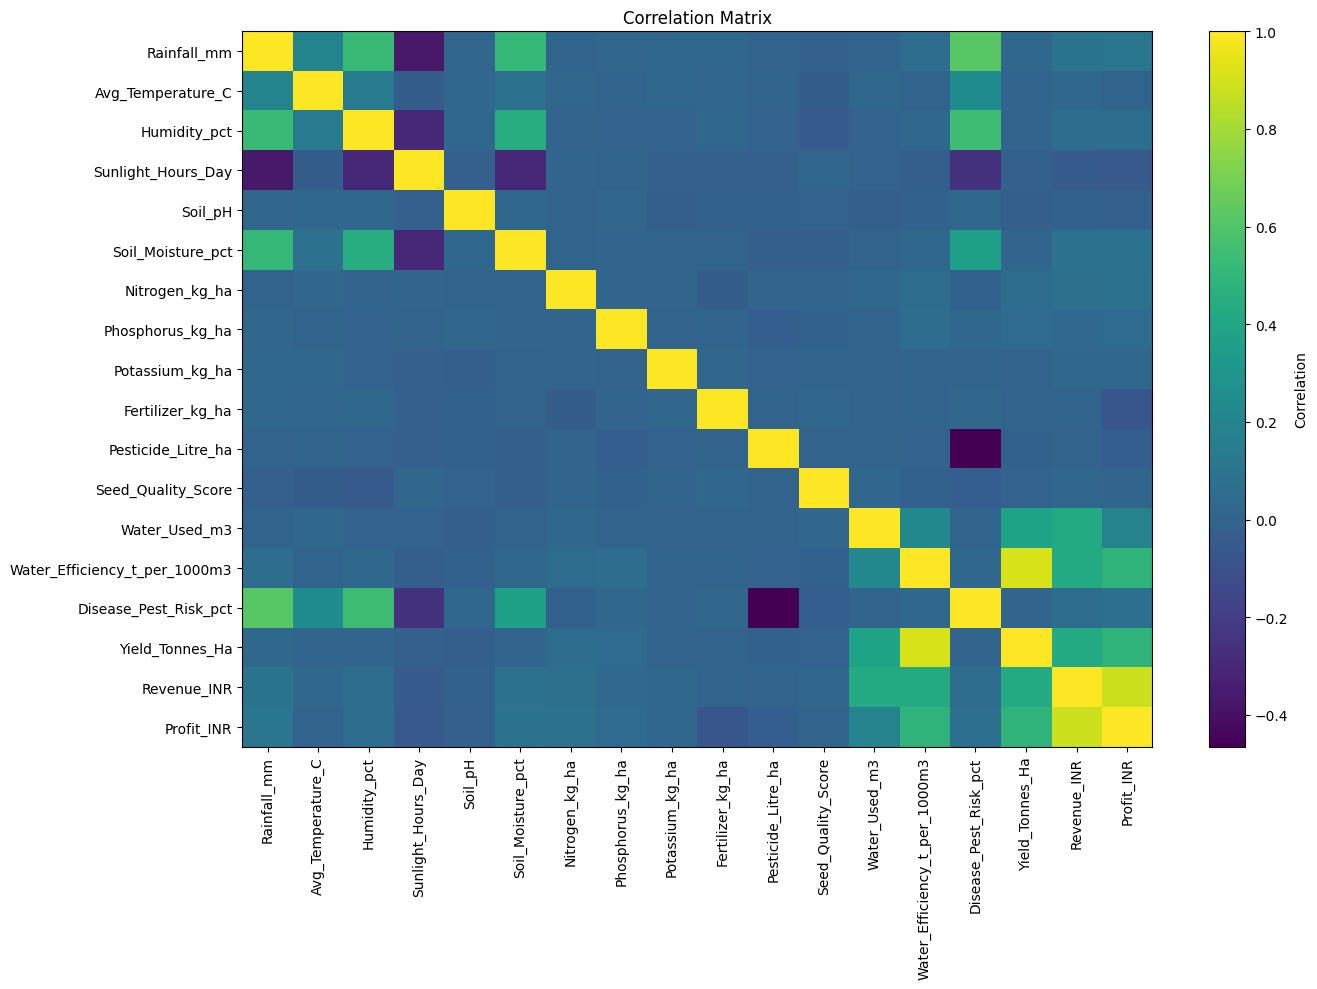

In [ ]:
# Correlations with key outcomes
corr_cols = [
    'Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day',
    'Soil_pH','Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha',
    'Potassium_kg_ha','Fertilizer_kg_ha','Pesticide_Litre_ha',
    'Seed_Quality_Score','Water_Used_m3','Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct','Yield_Tonnes_Ha','Revenue_INR','Profit_INR'
]
corr = clean[corr_cols].corr(numeric_only=True)
display(corr[['Yield_Tonnes_Ha','Profit_INR']].sort_values('Profit_INR', ascending=False))

plt.figure(figsize=(14,10))
plt.imshow(corr, aspect='auto', interpolation='nearest')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


## 10. Statistical testing
Because Season has three independent groups, one-way ANOVA is used to test whether mean yield/profit differs across seasons. Kruskal–Wallis is also reported as a non-parametric check. These tests identify group differences but do not establish causation.

In [ ]:
# ANOVA and Kruskal-Wallis tests
season_groups_yield = [g['Yield_Tonnes_Ha'].values for _, g in clean.groupby('Season')]
season_groups_profit = [g['Profit_INR'].values for _, g in clean.groupby('Season')]

anova_yield = stats.f_oneway(*season_groups_yield)
anova_profit = stats.f_oneway(*season_groups_profit)
kw_yield = stats.kruskal(*season_groups_yield)
kw_profit = stats.kruskal(*season_groups_profit)

tests = pd.DataFrame({
    'Outcome':['Yield_Tonnes_Ha','Profit_INR'],
    'ANOVA_F':[anova_yield.statistic, anova_profit.statistic],
    'ANOVA_p':[anova_yield.pvalue, anova_profit.pvalue],
    'Kruskal_H':[kw_yield.statistic, kw_profit.statistic],
    'Kruskal_p':[kw_yield.pvalue, kw_profit.pvalue]
})
display(tests.round(6))

print('Interpretation rule: p < 0.05 indicates evidence of a statistically significant difference among at least one pair of seasons.')


,Outcome,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p
0,Yield_Tonnes_Ha,1.54,0.21,68.71,0.00
1,Profit_INR,34.29,0.00,101.93,0.00


Interpretation rule: p < 0.05 indicates evidence of a statistically significant difference among at least one pair of seasons.


## 11. Unusual patterns / outliers

In [ ]:
# IQR-based outlier counts for major numeric outcomes
def outlier_info(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3-q1
    lo, hi = q1-1.5*iqr, q3+1.5*iqr
    mask = (series < lo) | (series > hi)
    return lo, hi, int(mask.sum()), round(mask.mean()*100,2)

outlier_rows=[]
for col in ['Yield_Tonnes_Ha','Profit_INR','Revenue_INR','Water_Used_m3','Water_Efficiency_t_per_1000m3']:
    lo, hi, n, pct = outlier_info(clean[col])
    outlier_rows.append([col, lo, hi, n, pct])
outlier_table=pd.DataFrame(outlier_rows, columns=['Variable','Lower_Bound','Upper_Bound','Outliers','Outlier_%'])
display(outlier_table)

# Show highest/lowest profit observations for investigation
display(clean.nlargest(5,'Profit_INR')[['Farm_ID','State','Crop','Season','Yield_Tonnes_Ha','Revenue_INR','Total_Cost_INR','Profit_INR']])
display(clean.nsmallest(5,'Profit_INR')[['Farm_ID','State','Crop','Season','Yield_Tonnes_Ha','Revenue_INR','Total_Cost_INR','Profit_INR']])


,Variable,Lower_Bound,Upper_Bound,Outliers,Outlier_%
0,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
1,Profit_INR,"-696,111.00","763,567.00",404,10.10
2,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
3,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
4,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05


,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha,Revenue_INR,Total_Cost_INR,Profit_INR
2236,SF12237,Punjab,Chilli,Kharif,3.90,5057448,712027,4345421
626,SF10627,Maharashtra,Chilli,Kharif,2.92,5080900,1059050,4021850
3425,SF13426,Madhya Pradesh,Sugarcane,Kharif,82.68,4485260,745161,3740099
1690,SF11691,Karnataka,Chilli,Kharif,3.01,4522464,784135,3738329
247,SF10248,Maharashtra,Chilli,Kharif,3.09,4825365,1283161,3542204


,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha,Revenue_INR,Total_Cost_INR,Profit_INR
780,SF10781,Andhra Pradesh,Groundnut,Rabi,0.30,280139,1299362,-1019223
2210,SF12211,Andhra Pradesh,Wheat,Rabi,0.30,102497,1097692,-995195
3625,SF13626,Punjab,Maize,Rabi,0.97,226503,1207553,-981050
2182,SF12183,Andhra Pradesh,Rice,Kharif,1.01,320865,1297725,-976860
104,SF10105,Gujarat,Wheat,Zaid,0.30,98792,1063989,-965197


## 12. Evidence-based conclusions and recommendations

In [ ]:
# Automatically generate concise evidence statements from the analysis
best_profit_season = performance['Avg_Profit_INR'].idxmax()
best_yield_season = performance['Avg_Yield_t_ha'].idxmax()
best_water_season = performance['Avg_Water_Efficiency'].idxmax()
best_crop = crop_perf['Avg_Profit'].idxmax()
best_irrigation = irrigation['Avg_Profit'].idxmax()
best_state = state_perf['Avg_Profit'].idxmax()

print('KEY FINDINGS')
print(f'1. Highest average profit season: {best_profit_season} (INR {performance.loc[best_profit_season,"Avg_Profit_INR"]:,.2f}).')
print(f'2. Highest average yield season: {best_yield_season} ({performance.loc[best_yield_season,"Avg_Yield_t_ha"]:,.2f} tonnes/ha).')
print(f'3. Highest average water-efficiency season: {best_water_season} ({performance.loc[best_water_season,"Avg_Water_Efficiency"]:,.2f} tonnes per 1,000 m³).')
print(f'4. Highest average-profit crop: {best_crop} (INR {crop_perf.loc[best_crop,"Avg_Profit"]:,.2f}).')
print(f'5. Highest average-profit irrigation method: {best_irrigation} (INR {irrigation.loc[best_irrigation,"Avg_Profit"]:,.2f}).')
print(f'6. Highest average-profit state: {best_state} (INR {state_perf.loc[best_state,"Avg_Profit"]:,.2f}).')

print('\nRECOMMENDATIONS')
print('• Use the strongest-performing seasonal practices as a benchmark, while considering differences in environmental conditions.')
print('• Plan water and irrigation resources around observed seasonal water-use and efficiency patterns.')
print('• Investigate crop and regional combinations with consistently higher profit before scaling practices.')
print('• Monitor high-risk seasons/areas for disease and pest exposure and evaluate preventive measures.')
print('• Treat extreme observations as cases for investigation rather than automatically removing them.')
print('• Use statistical results together with operational context; correlation and group differences do not by themselves prove causation.')


KEY FINDINGS
1. Highest average profit season: Kharif (INR 178,914.65).
2. Highest average yield season: Kharif (5.63 tonnes/ha).
3. Highest average water-efficiency season: Kharif (5.89 tonnes per 1,000 m³).
4. Highest average-profit crop: Sugarcane (INR 817,187.99).
5. Highest average-profit irrigation method: Drip (INR 219,626.00).
6. Highest average-profit state: Punjab (INR 136,025.64).

RECOMMENDATIONS
• Use the strongest-performing seasonal practices as a benchmark, while considering differences in environmental conditions.
• Plan water and irrigation resources around observed seasonal water-use and efficiency patterns.
• Investigate crop and regional combinations with consistently higher profit before scaling practices.
• Monitor high-risk seasons/areas for disease and pest exposure and evaluate preventive measures.
• Treat extreme observations as cases for investigation rather than automatically removing them.
• Use statistical results together with operational context; correl

In [ ]:
# Save the cleaned dataset for reuse
clean.to_csv('cleaned_seasonal_agriculture_performance_dataset.csv', index=False)
print('Saved: cleaned_seasonal_agriculture_performance_dataset.csv')


Saved: cleaned_seasonal_agriculture_performance_dataset.csv
